#### Testing to downlaod data from sources and extract subsets for the given time interval [t0, t1], and prepare lompe.Data objects.

#### This is a test script to check the data downloading and subset extraction functions. The same example used in the lompe paper to comparison with the results in the paper.


In [1]:
from lompe.data_tools import dataloader
from lompe.data_tools.get_lompe_data import get_data_subsets, prepare_event_data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import lompe
import apexpy
# cubed sphere grid parameters:
position = (-90, 68)  # lon, lat for grid center
orientation = 0       # angle of grid x axis - anti-clockwise from east direction
L, W = 7000e3, 3800e3 # extents [m] of grid
dL, dW = 100e3, 100e3 # spatial resolution [m] of grid 
# create grid object
grid = lompe.cs.CSgrid(lompe.cs.CSprojection(position, orientation), L, W, dL, dW, R = 6481.2e3)

In [2]:
event = '2012-04-05'
date_str = event + 'T' + '05:12:00'
T0 = dt.datetime.strptime(date_str, '%Y-%m-%dT%H:%M:%S')
delta_minutes = 4
DT = dt.timedelta(seconds = 60 * delta_minutes) # length of time interval
# apex object for plotting in magnetic
apex = apexpy.Apex(T0, refh = 110)
# making conductance tuples
Kp = 4 # this is the input to the Hardy model
SH = lambda lon = grid.lon, lat = grid.lat: lompe.conductance.hardy_EUV(lon, lat, Kp, T0, 'hall')
SP = lambda lon = grid.lon, lat = grid.lat: lompe.conductance.hardy_EUV(lon, lat, Kp, T0, 'pedersen')

# Create Emodel object. Pass grid and Hall/Pedersen conductance functions
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (SH, SP))

# add datasets to model (by default get_lompe_data will load superdarn, supermag, iridium and champ data if available)
# but data_tools are capabale of handling ssusi, ssies, and swarm data as well, get_lompe_data should be rewritten in that case.
event_data = prepare_event_data(event, sources=["superdarn", "supermag", "iridium", "champ"])
all_data= get_data_subsets(event_data, T0, delta_minutes=delta_minutes)
model.add_data(*all_data)

File already exists at:  ./sample_dataset/20120405_supermag.h5
File already exists at: ./sample_dataset/20120405_iridium.h5.
No champ data: Champ data available (2000-07-19 to 2010-09-17), returning: [Errno 8] nodename nor servname provided, or not known


ground_mag: Measurement uncertainty effectively changed from 1e-08 to 1.5811388300841896e-08
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.743416490252568e-08


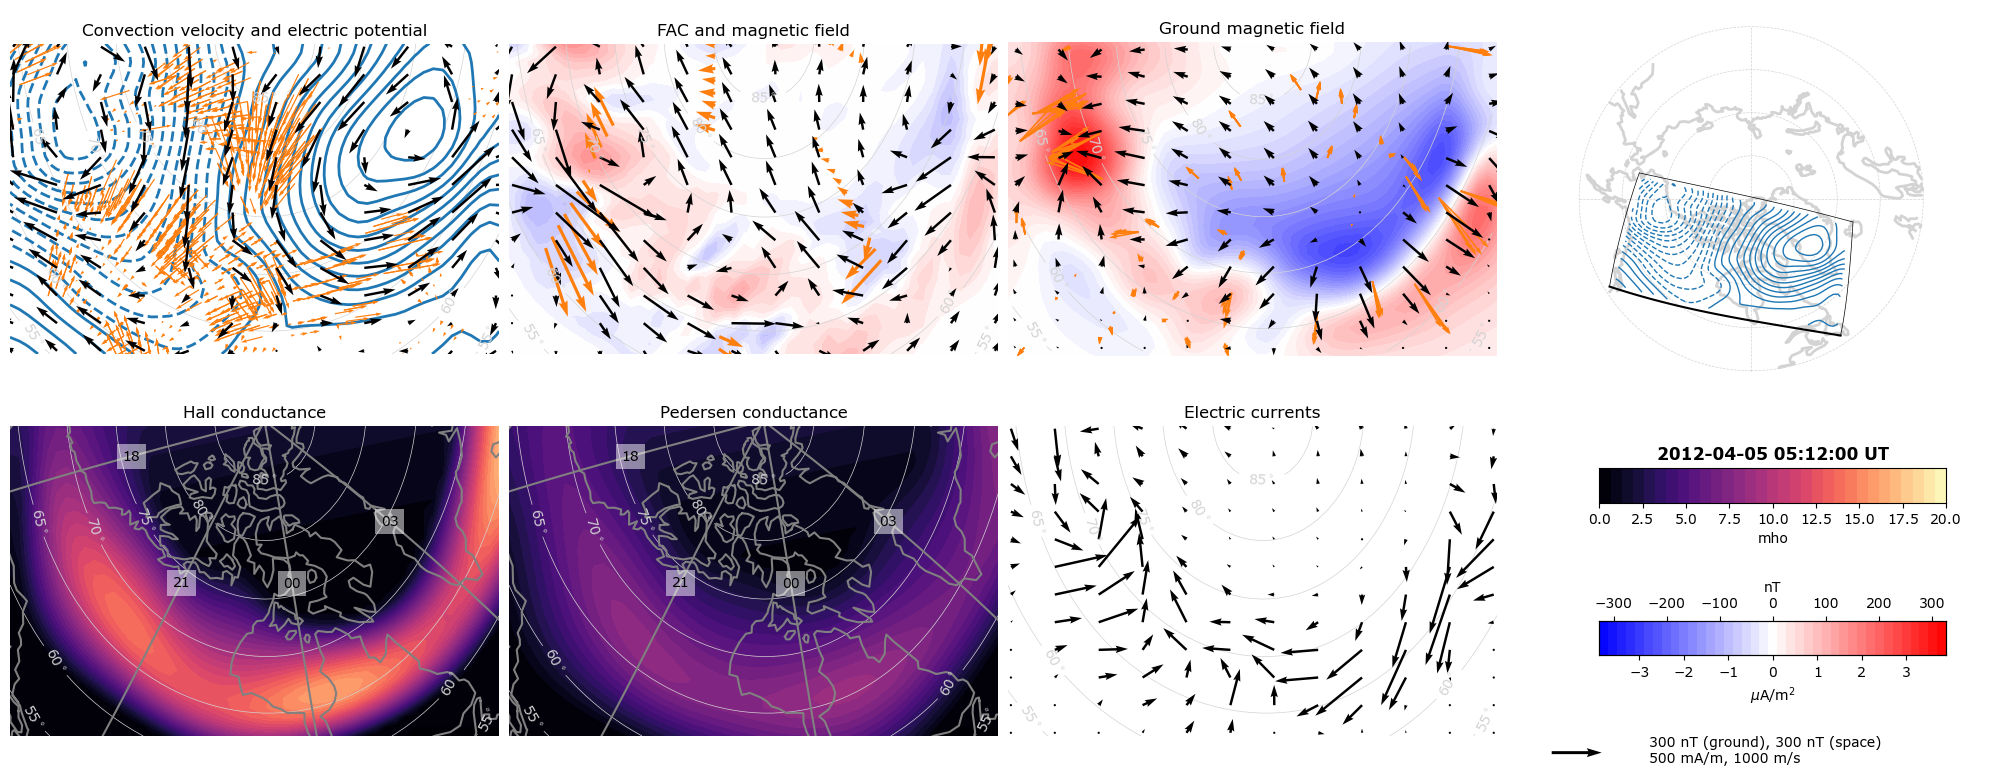

In [3]:
model.run_inversion(l1 = 1, l2 = 10)
# finally, plot (plot is saved as specified path):
fig = lompe.lompeplot(model, include_data = True, time = T0, apex = apex)